In [191]:
import pandas as pd
import os
import sys
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

src_path = '/Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/src'
if src_path not in sys.path:
    sys.path.append(src_path)

from data.load_data import load_data # type: ignore
from models.arima_model import * # type: ignore
from features.transform_features import split_column
from features.clean_features import extract_numeric

In [192]:
data = load_data('/Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/raw/Expanded_Cybersecurity_Dataset.csv')

In [193]:
# Set seed for reproducibility
np.random.seed(42)

# Define number of observations and generate a date range
n = 200
dates = pd.date_range(start='2020-01-01', periods=n, freq='D')

# Create components for the synthetic data:
# - A linear trend
trend = np.linspace(0, 10, n)

# - A seasonal component using a sine wave
seasonality = 5 * np.sin(np.linspace(0, 3 * np.pi, n))

# - Random noise
noise = np.random.normal(0, 1, n)

# Combine all components to form the time series data
data = trend + seasonality + noise

# Create a DataFrame
data = pd.DataFrame({'Date': dates, 'Value': data})

In [194]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [195]:
data.head()

,Value
Date,
2020-01-01,0.496714
2020-01-02,0.148702
2020-01-03,1.221090
2020-01-04,2.381806
2020-01-05,0.908410


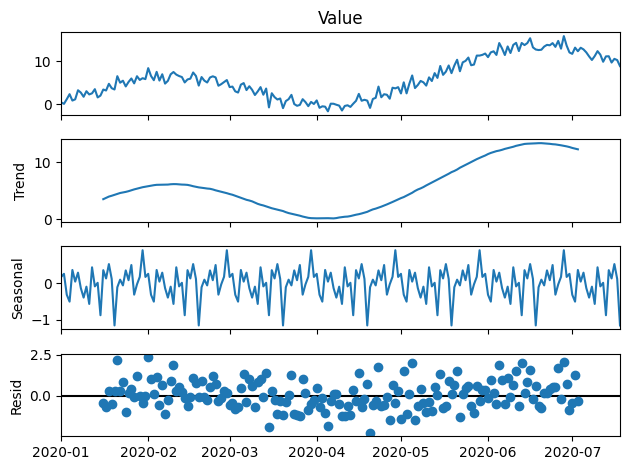

In [196]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure there are no missing values in the data
data_cleaned = data['Value'].dropna()

# Perform seasonal decomposition
result = seasonal_decompose(data_cleaned, model='additive', period=30)

# Plot the decomposition
result.plot()
plt.show()

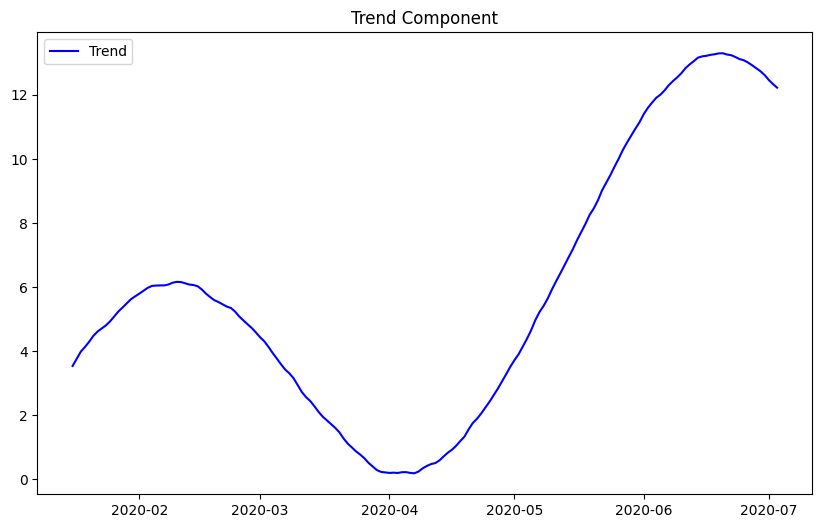

In [197]:
# Extract and plot the trend component
trend = result.trend
plt.figure(figsize=(10, 6))
plt.plot(trend, label='Trend', color='blue')
plt.title('Trend Component')
plt.legend()
plt.show()

The series is non-stationary after 0 differencing(s). Differencing again...
The series is non-stationary after 1 differencing(s). Differencing again...
The series is stationary after 2 differencing(s).


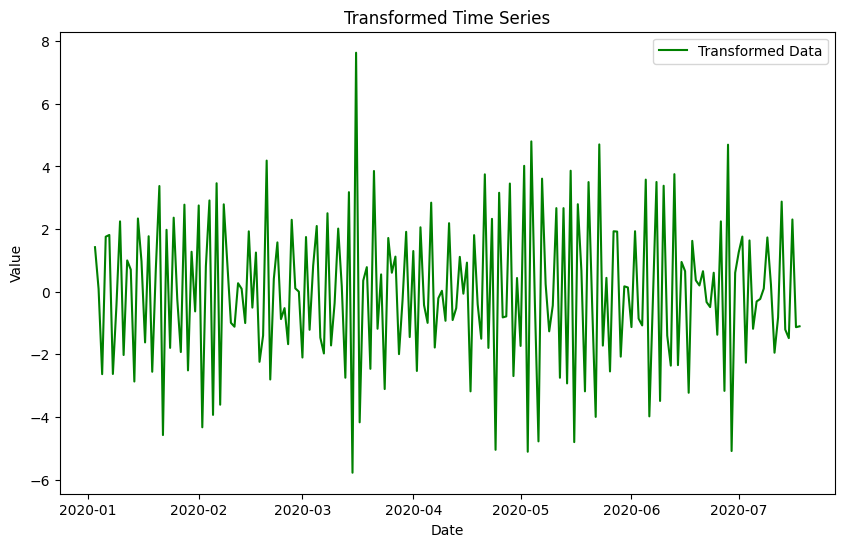

In [198]:
from statsmodels.tsa.stattools import adfuller

def make_stationary(data, column, max_diff=3):
    """
    Pipeline to check stationarity and difference the data up to a maximum number of times.

    Parameters:
    - data: DataFrame containing the time series data.
    - column: The column name of the time series.
    - max_diff: Maximum number of differencing steps.

    Returns:
    - DataFrame with the stationary time series.
    """
    for i in range(max_diff):
        # Perform the Augmented Dickey-Fuller test
        adf_test = adfuller(data[column])
        p_value = adf_test[1]
        key = '5%'

        # Check if the series is stationary
        if p_value <= 0.05 and adf_test[0] < adf_test[4][key]:
            print(f"The series is stationary after {i} differencing(s).")
            break
        else:
            print(f"The series is non-stationary after {i} differencing(s). Differencing again...")
            data[column] = data[column].diff()
            data.dropna(inplace=True)
    else:
        print(f"The series is still non-stationary after {max_diff} differencing(s).")

    return data

# Apply the pipeline to the data
data = make_stationary(data, 'Value', max_diff=3)

# Plot the final differenced data
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Value'], label='Transformed Data', color='green')
plt.title('Transformed Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def analyze_acf_pacf(data, acf_values, pacf_values, conf_level):

    # Calculate first significant ACF lag (excluding lag 0)
    first_sig_acf_lag = next(i for i, val in enumerate(acf_values[1:], start=1) if abs(val) > conf_level)

    # Calculate first significant PACF lag
    first_sig_pacf_lag = next(i for i, val in enumerate(pacf_values[1:], start=1) if abs(val) > conf_level)

    print(f"First significant ACF lag: {first_sig_acf_lag}")
    print(f"First significant PACF lag: {first_sig_pacf_lag}")

    # Plot the autocorrelation function (ACF)
    plt.figure(figsize=(10, 6))
    plot_acf(data['Value'], lags=30, ax=plt.gca())
    plt.title('Autocorrelation Function (ACF)')
    plt.show()

    # Plot the partial autocorrelation function (PACF)
    plt.figure(figsize=(10, 6))
    plot_pacf(data['Value'], lags=30, ax=plt.gca(), method='ywm')
    plt.title('Partial Autocorrelation Function (PACF)')
    plt.show()

    return {
        "first_sig_acf_lag": first_sig_acf_lag,
        "first_sig_pacf_lag": first_sig_pacf_lag
}

results = analyze_acf_pacf(data, acf_values, pacf_values, conf_level)

First significant ACF lag: 1
First significant PACF lag: 1


### Interpreting ACF and PACF Plots

Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are essential tools in time series analysis, particularly for identifying the order of ARIMA models.

---

#### 1. **Autocorrelation Function (ACF)**
- **Definition**: ACF measures the correlation between the time series and its lagged values.
- **Purpose**: Helps identify the order of the Moving Average (MA) component in an ARIMA model.
- **Interpretation**:
  - Significant spikes at lag `k` indicate that the lagged value at `k` is correlated with the current value.
  - A gradual decay in the ACF plot suggests the presence of a non-stationary series.
  - A sharp cutoff after a few lags indicates the order of the MA component.

---

#### 2. **Partial Autocorrelation Function (PACF)**
- **Definition**: PACF measures the correlation between the time series and its lagged values, after removing the effects of intermediate lags.
- **Purpose**: Helps identify the order of the Auto-Regressive (AR) component in an ARIMA model.
- **Interpretation**:
  - Significant spikes at lag `k` indicate that the lagged value at `k` contributes to the series after accounting for intermediate lags.
  - A sharp cutoff in the PACF plot suggests the order of the AR component.

---

#### 3. **Key Patterns to Look For**
- **Stationary Series**:
  - **ACF**: Rapid decay to zero.
  - **PACF**: Rapid decay to zero.
- **Non-Stationary Series**:
  - **ACF**: Slow decay or sinusoidal pattern.
  - **PACF**: Significant spikes at initial lags.
- **AR Process**:
  - **ACF**: Gradual decay.
  - **PACF**: Sharp cutoff after `p` lags.
- **MA Process**:
  - **ACF**: Sharp cutoff after `q` lags.
  - **PACF**: Gradual decay.

---

#### 4. **Practical Tips**
- Use the **ACF plot** to determine the order of the MA component (`q`).
- Use the **PACF plot** to determine the order of the AR component (`p`).
- If the series is non-stationary, consider differencing it before analyzing the ACF and PACF plots.

In [199]:
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define a range of SARIMA orders to evaluate
sarima_orders = [
    ((p, d, q), (P, D, Q, s))
    for p in range(1, 4)  # Range for p
    for d in range(0, 2)  # Range for d
    for q in range(1, 4)  # Range for q
    for P in range(0, 2)  # Range for P
    for D in range(0, 2)  # Range for D
    for Q in range(0, 2)  # Range for Q
    for s in [12, 24]     # Seasonal periods
]

# Evaluate each SARIMA order and store the AIC values
aic_values = []
for order, seasonal_order in sarima_orders:
    try:
        model = SARIMAX(train['Value'], 
                        order=order, 
                        seasonal_order=seasonal_order, 
                        enforce_stationarity=False, 
                        enforce_invertibility=False)
        result = model.fit(disp=False)
        aic_values.append((order, seasonal_order, result.aic))
    except Exception as e:
        print(f"Failed to fit SARIMA{order}x{seasonal_order}: {e}")

# Sort the results by AIC and get the top 5
top_5_orders = sorted(aic_values, key=lambda x: x[2])[:5]

# Print the top 5 SARIMA orders
print("Top 5 SARIMA Orders based on AIC:")
for order, seasonal_order, aic in top_5_orders:
    print(f"SARIMA{order}x{seasonal_order} - AIC: {aic}")

In [ ]:
metrics_df = pd.DataFrame(columns=["Order", "Seasonal_Order", "MAE", "MSE", "RMSE", "MAPE", "R2"])
if not isinstance(metrics_storage, list):
    metrics_storage = []

In [210]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = (3, 1, 5)
seasonal_order = (0, 0, 1, 24)

# Fit a SARIMA model
sarima_model = SARIMAX(train['Value'], 
                       order=order, 
                       seasonal_order=seasonal_order, 
                       enforce_stationarity=False, 
                       enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# Print the summary of the SARIMA model
print(sarima_result.summary())
import plotly.graph_objects as go

# Create an interactive plot
fig = go.Figure()

# Add observed data
fig.add_trace(go.Scatter(x=data.index, y=data['Value'], mode='lines', name='Observed', line=dict(color='blue')))

# Generate forecasted values
forecast = sarima_result.get_forecast(steps=len(data))
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Add forecasted values
fig.add_trace(go.Scatter(x=forecast_values.index, y=forecast_values, mode='lines', name='Forecast', line=dict(color='orange')))

# Add confidence intervals
fig.add_trace(go.Scatter(
    x=confidence_intervals.index.tolist() + confidence_intervals.index[::-1].tolist(),
    y=confidence_intervals.iloc[:, 0].tolist() + confidence_intervals.iloc[:, 1][::-1].tolist(),
    fill='toself',
    fillcolor='rgba(128, 128, 128, 0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Confidence Interval'
))

# Update layout for clarity
fig.update_layout(
    title='Forecasted Threat Event Count',
    xaxis_title='Date',
    yaxis_title='Threat Event Count',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template='plotly_white'
)

# Show the interactive plot
fig.show()
predictions = sarima_result.predict(start=test.index[0], end=test.index[-1])


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                                      SARIMAX Results                                       
Dep. Variable:                                Value   No. Observations:                  158
Model:             SARIMAX(3, 1, 5)x(0, 0, [1], 24)   Log Likelihood                -190.239
Date:                              Mon, 31 Mar 2025   AIC                            400.479
Time:                                      12:49:18   BIC                            428.920
Sample:                                  01-03-2020   HQIC                           412.034
                                       - 06-08-2020                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4318      0.478     -2.998      0.003      -2.368      -0.496
ar.L2         -0.67

MAE: 1.6250
MSE: 4.0910
RMSE: 2.0226
MAPE: 99.91%
R² Score: 0.0528

Model Fit Evaluation:
Model needs improvement.


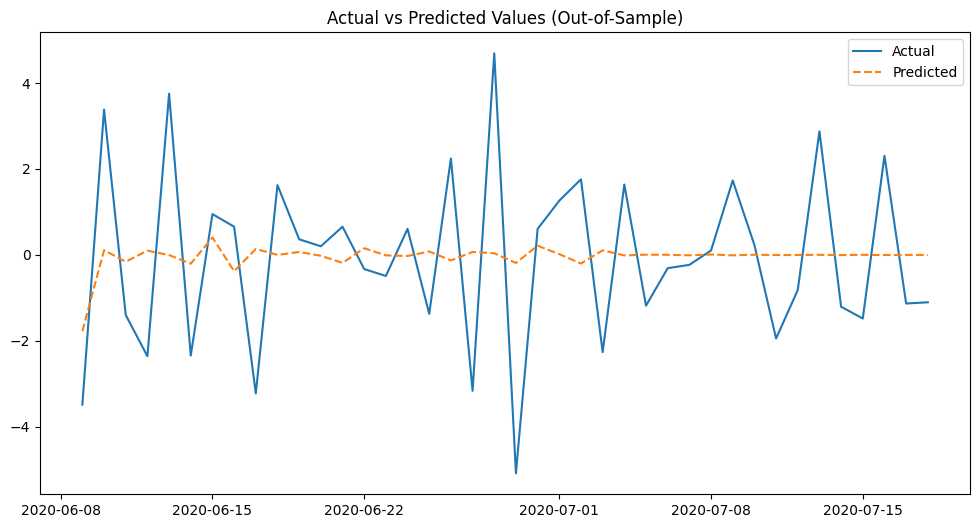

       Order  Seaonal_Order       MAE       MSE      RMSE       MAPE        R2
0  (3, 0, 3)  (0, 0, 1, 24)  1.620989  4.072669  2.018085  99.572144  0.057014
1  (3, 1, 3)  (0, 0, 1, 24)  1.591980  3.920326  1.979981  99.643573  0.092288


In [215]:
# Initialize storage
current_order = None
current_seasonal_order = None
best_metrics = metrics_storage[0] if metrics_storage else None
previous_metrics = best_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def evaluate_model_pipeline(actual, predictions, order, seasonal_order):
    global current_metrics, current_order, current_seasonal_order, metrics_df, metrics_storage

    # Calculate metrics
    mae = mean_absolute_error(actual, predictions)
    mse = mean_squared_error(actual, predictions)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    r2 = r2_score(actual, predictions)

    current_metrics = {'Order': order, 'Seaonal_Order': seasonal_order, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

    # Define thresholds
    mae_thresh = actual.mean() * 0.1
    rmse_thresh = actual.std() * 0.5

    # Print metrics
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R² Score: {r2:.4f}")
    print("\nModel Fit Evaluation:")

    if mae < mae_thresh and rmse < rmse_thresh:
        print("Model is highly accurate and has a good fit.")
    elif mae < mae_thresh * 2 and rmse < rmse_thresh * 2:
        print("Model is moderately accurate and has an acceptable fit.")
    else:
        print("Model needs improvement.")

    # Store metrics
    if not metrics_storage:
        metrics_storage.append(current_metrics)
    elif mae < best_metrics['MAE']:
        print("New best model found!")
        metrics_storage.append(current_metrics)   
          
    plt.figure(figsize=(12, 6))
    plt.plot(actual.index, actual, label='Actual')
    plt.plot(predictions.index, predictions, label='Predicted', linestyle='--')
    plt.legend()
    plt.title("Actual vs Predicted Values (Out-of-Sample)")
    plt.show()

    pd.set_option('display.width', 1000)  # Increase the width
    pd.set_option('display.max_columns', None)  # Ensure all columns are displayed


# Example usage
metrics = evaluate_model_pipeline(test['Value'], predictions, order, seasonal_order)

best_metrics = pd.DataFrame(metrics_storage)
print(best_metrics)



In [212]:
previous_metrics = pd.DataFrame(metrics_storage)
print(previous_metrics)

       Order  Seaonal_Order       MAE       MSE      RMSE       MAPE        R2
0  (3, 0, 3)  (0, 0, 1, 24)  1.620989  4.072669  2.018085  99.572144  0.057014
1  (3, 1, 3)  (0, 0, 1, 24)  1.591980  3.920326  1.979981  99.643573  0.092288


In [213]:
best_metrics = pd.DataFrame(metrics_storage)
print(best_metrics)

       Order  Seaonal_Order       MAE       MSE      RMSE       MAPE        R2
0  (3, 0, 3)  (0, 0, 1, 24)  1.620989  4.072669  2.018085  99.572144  0.057014
1  (3, 1, 3)  (0, 0, 1, 24)  1.591980  3.920326  1.979981  99.643573  0.092288


In [214]:
current_metrics = pd.DataFrame(metrics_storage)
print(current_metrics)

       Order  Seaonal_Order       MAE       MSE      RMSE       MAPE        R2
0  (3, 0, 3)  (0, 0, 1, 24)  1.620989  4.072669  2.018085  99.572144  0.057014
1  (3, 1, 3)  (0, 0, 1, 24)  1.591980  3.920326  1.979981  99.643573  0.092288
